DATA ENGINEERING MINI PROJECT REPORT
----------------------------------------
[1] Loading the dataset
----------------------------------------
----------------------------------------
[2] Exploring the dataset
----------------------------------------
Number of rows:30
Number of columns:13
Column names:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
First five rows:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_scor

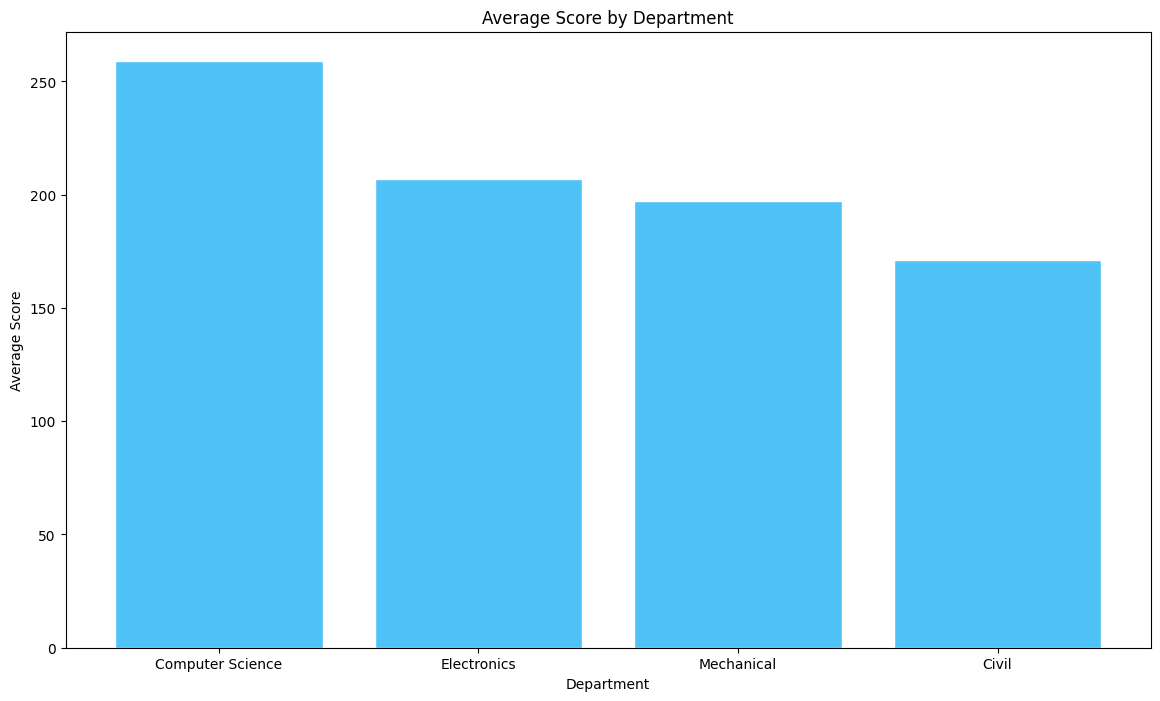

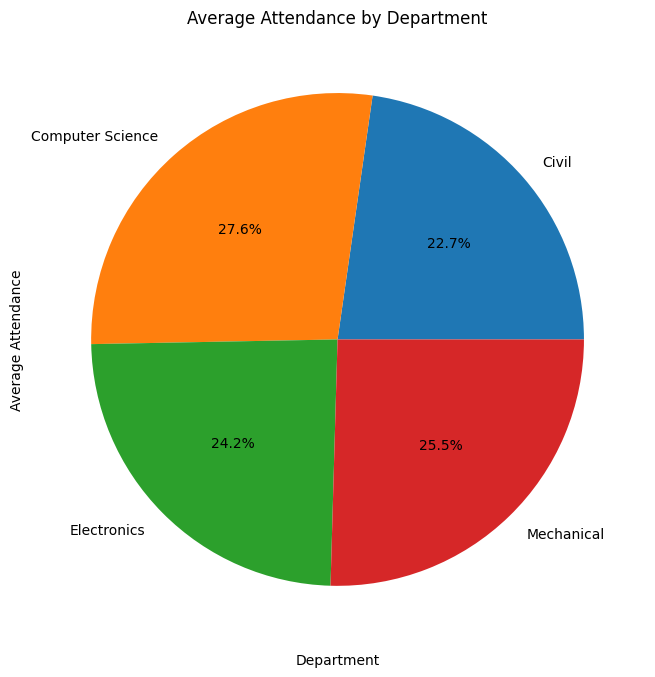

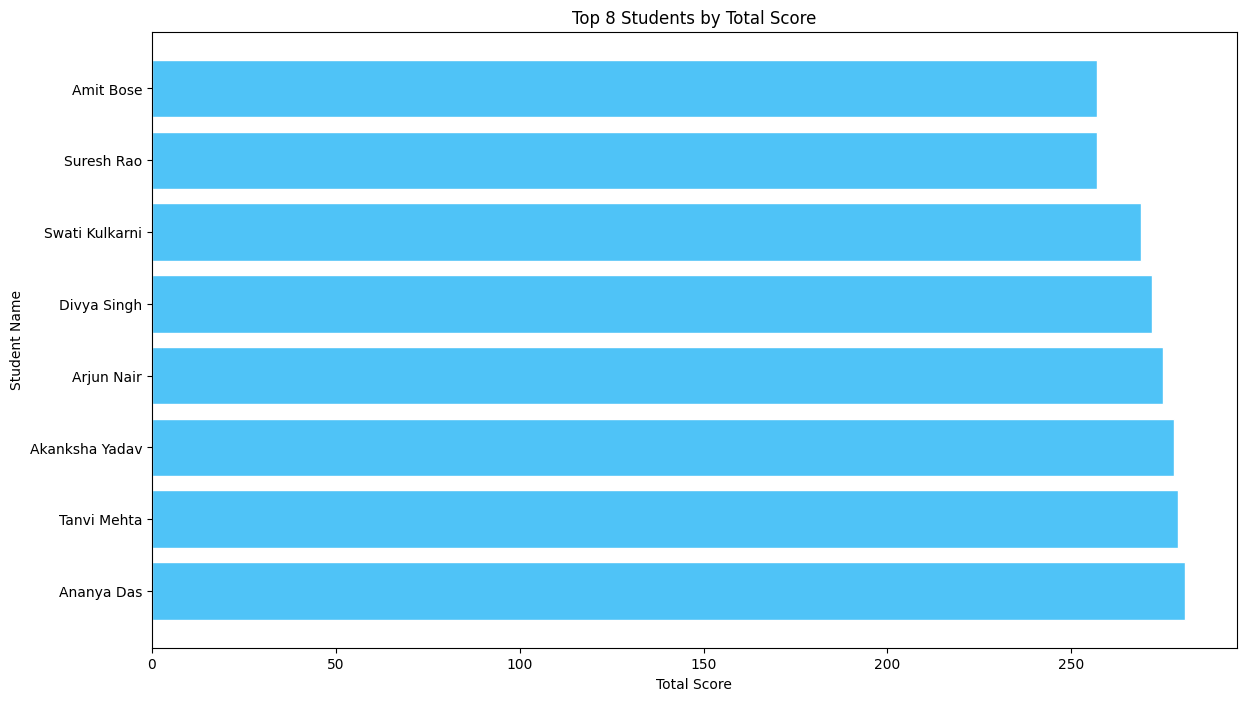

----------------------------------------
[10] ML Prediction
----------------------------------------
Mean Absolute Error:9.771666666666667
Mean Squared Error:167.04805000000002
R-squared:0.6642062761739908
Predicted Programming Score:90.13


In [14]:
print('='*50)
print("DATA ENGINEERING MINI PROJECT REPORT")
print('='*50)
#loading the dataset
print('-'*40)
print("[1] Loading the dataset")
print('-'*40)
import pandas as pd
df=pd.read_csv("student_performance.csv")
#exploring the dataset
print('-'*40)
print("[2] Exploring the dataset")
print('-'*40)
print(f"Number of rows:{df.shape[0]}")
print(f"Number of columns:{df.shape[1]}")
print(f"Column names:{df.columns.tolist()}")
print(f"First five rows:\n{df.head()}")
print(f"Summary statistics:\n{df.describe()}")
#cleaning
print('-'*40)
print("[3] Cleaning the dataset")
print('-'*40)
print("\nMissing values per column")
print(df.isnull().sum())
print(f"\nDuplicate rows:{df.duplicated().sum()}")
#SQL
print('-'*40)
print("[4] SQL")
print('-'*40)
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')
conn=sqlite3.connect('students.db')
cursor=conn.cursor()
df.to_sql('students',conn,if_exists='replace',index=False)
cursor.execute("SELECT * FROM students LIMIT 5")
result=cursor.fetchall()
print(result)
def run_query(sql,description=""):
  if description:
    print(f"\n{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result
query1="SELECT name, gender from students"
run_query(query1,"name and gender of students")
query2="SELECT name , math_score from students ORDER BY math_score desc LIMIT 5"
run_query(query2," display name and math score of top 5 students based on math score")
query3="SELECT name,math_score,science_score,programming_score,attendance_percentage from students where department='Computer Science' order by programming_score desc LIMIT 5"
run_query(query3,"top 5 students from cumputer science department based on progrmming score")
query4="select name,department,attendance_percentage from students where attendance_percentage>90 and department!='Civil'order by attendance_percentage desc"
run_query(query4,"students with attendance_percentage>90 and not from civil department")
query5="select department, count(*) as no_of_students,round(avg(math_score),2)as avg_math,round(avg(science_score),2)as avg_science,round(avg(programming_score))as avg_peogramming,round(avg(attendance_percentage))as avg_attendance from students group by department"
run_query(query5,"department wise average")
#pyspark
print('-'*40)
print("[5] PySpark")
print('-'*40)
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.sql.functions import year,month,to_date,col,round as spark_round


import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

spark=SparkSession.builder \
    .appName('STUDENTS')\
    .config('spark.sql.adaptive','true') \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"SparkSession: Active")
print(f"Application: {spark.sparkContext.appName}")
df_bronze= spark.read \
  .option('header','true') \
  .option('inferSchema','true')\
  .csv('student_performance.csv')
print("===Bronze layer - raw data")
print(f"rows :{df_bronze.count()}")
print(f"columns :{len(df_bronze.columns)}")
#BRONZE
print('-'*40)
print("[6] Bronze layer")
print('-'*40)
df_bronze.write \
    .mode('overwrite')\
    .parquet('students_bronze.parequet')
print("bronze Parquetsaced successfully")

import os
def get_dir_size(path):
    if os.path.exists(path):
        return os.path.getsize(path)/1024
    total=0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            total+=os.path.getsize(os.path.join(dirpath,f))
    return total/1024
csv_size=get_dir_size('student_performance.csv')
#SILVER
print('-'*40)
print("[7] Silver layer")
print('-'*40)
df_silver=spark.read.parquet('students_bronze.parequet')
print(f"rows :{df_silver.count()}")
print(f"columns :{len(df_silver.columns)}")
df_silver=df_silver.withColumn('total_score',col("math_score") + col("science_score") + col("english_score")+col('programming_score'))
df_silver=df_silver.withColumn('category',
                               F.when(col('total_score')>300,'GOOD')
                               .when(col('total_score')>=200,'AVERAGE')
                               .otherwise('POOR'))

df_silver.write \
    .mode('overwrite')\
    .parquet('students_silver.parequet')
print("silver Parquetsaced successfully")
#GOLD
print('-'*40)
print("[8] Gold layer")
print('-'*40)
df_gold=spark.read.parquet('students_silver.parequet')
print(f"rows :{df_gold.count()}")
print(f"columns :{len(df_gold.columns)}")
dept_score=df_silver\
.groupBy('department')\
.agg(
    F.round(F.avg('total_score').alias('avg_score'),2),
)
gold_dept=dept_score


gold_dept.write \
    .mode('overwrite')\
    .parquet('students_gold.parequet')
print("gold departmnet wise avg total score Parquetsaced successfully")
#visualize
print('-'*40)
print("[9] Visualization")
print('-'*40)
import matplotlib.pyplot as plt
import pandas as pd
fig, axs = plt.subplots(figsize=(14, 8))
ch1="SELECT department,ROUND(AVG(math_score + science_score + programming_score)) as avg_score FROM students GROUP BY department ORDER BY avg_score DESC"
ch1_data=pd.read_sql_query(ch1,conn)
bars=plt.bar(ch1_data['department'],ch1_data['avg_score'],color='#4FC3F7',edgecolor='white')
axs.set_title('Average Score by Department')
axs.set_xlabel('Department')
axs.set_ylabel('Average Score')
plt.show()
fig, axs = plt.subplots(figsize=(14, 8))
ch2="SELECT department,ROUND(AVG(attendance_percentage)) as avg_attendance FROM students GROUP BY department"
ch2_data=pd.read_sql_query(ch2,conn)
bars=plt.pie(ch2_data['avg_attendance'],labels=ch2_data['department'],autopct='%1.1f%%')
axs.set_title('Average Attendance by Department')
axs.set_xlabel('Department')
axs.set_ylabel('Average Attendance')
plt.show()
fig, axs = plt.subplots(figsize=(14, 8))
ch3="SELECT name,math_score+science_score+programming_score as total_score FROM students ORDER BY total_score DESC LIMIT 8"
ch3_data=pd.read_sql_query(ch3,conn)
bars=plt.barh(ch3_data['name'],ch3_data['total_score'],color='#4FC3F7',edgecolor='white')
axs.set_title('Top 8 Students by Total Score')
axs.set_xlabel('Total Score')
axs.set_ylabel('Student Name')
plt.show()
#ML pREDICTION
print('-'*40)
print("[10] ML Prediction")
print('-'*40)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

x=df[['math_score','science_score','english_score']]
y=df['programming_score']
model=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
y_predict=model.predict(x_test)
mae=mean_absolute_error(y_test,y_predict)
mse=mean_squared_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)
print(f"Mean Absolute Error:{mae}")
print(f"Mean Squared Error:{mse}")
print(f"R-squared:{r2}")
import joblib
joblib.dump(model,'programming_score_model.pkl')
b=joblib.load('programming_score_model.pkl')
prediction_input=pd.DataFrame([[85,90,70]])
predicted_score=b.predict(prediction_input)
print(f"Predicted Programming Score:{predicted_score[0]}")
